In [7]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor




In [8]:
# Raw data


# Clinical Data
df = pl.read_csv("../data/raw/X_train/clinical_train.csv")
df_eval = pl.read_csv("../data/raw/X_test/clinical_test.csv")



# TRAITEMENT DE CLINICAL DATA SET


In [9]:
# Clinical Data
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,109,272,193,601,110,124,387


In [10]:
df.describe()

statistic,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,str,f64,f64,f64,f64,f64,f64,str
"""count""","""3323""","""3323""",3214.0,3051.0,3130.0,2722.0,3213.0,3199.0,"""2936"""
"""null_count""","""0""","""0""",109.0,272.0,193.0,601.0,110.0,124.0,"""387"""
"""mean""",null,null,5.982545,6.535164,3.264735,0.955868,9.893549,167.0489,null
"""std""",null,null,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031,null
"""min""","""P100000""","""CCH""",0.0,0.2,0.0,0.0,4.0,2.0,"""+8(fish)"""
"""25%""",null,null,1.0,2.7,1.0,0.15,8.5,66.0,null
"""50%""",null,null,3.0,4.1,2.0,0.37,9.7,123.0,null
"""75%""",null,null,8.0,6.66,3.69,0.784,11.2,230.0,null
"""max""","""P132729""","""VU""",91.0,154.4,109.62,44.2,16.6,1451.0,"""tris8"""


In [11]:
quant_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]
sub_df = df.select(quant_vars)

# Convert to pandas
sub_pd = sub_df.to_pandas()

# Apply Model-Based Imputation (Random Forest)
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=42)
imputed_data = imputer.fit_transform(sub_pd)

# 4. To Polars
imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

# 5. Replace nulls
df = df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [12]:
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,387


# OUTLIERS TREATEMENT

# Method IQR 

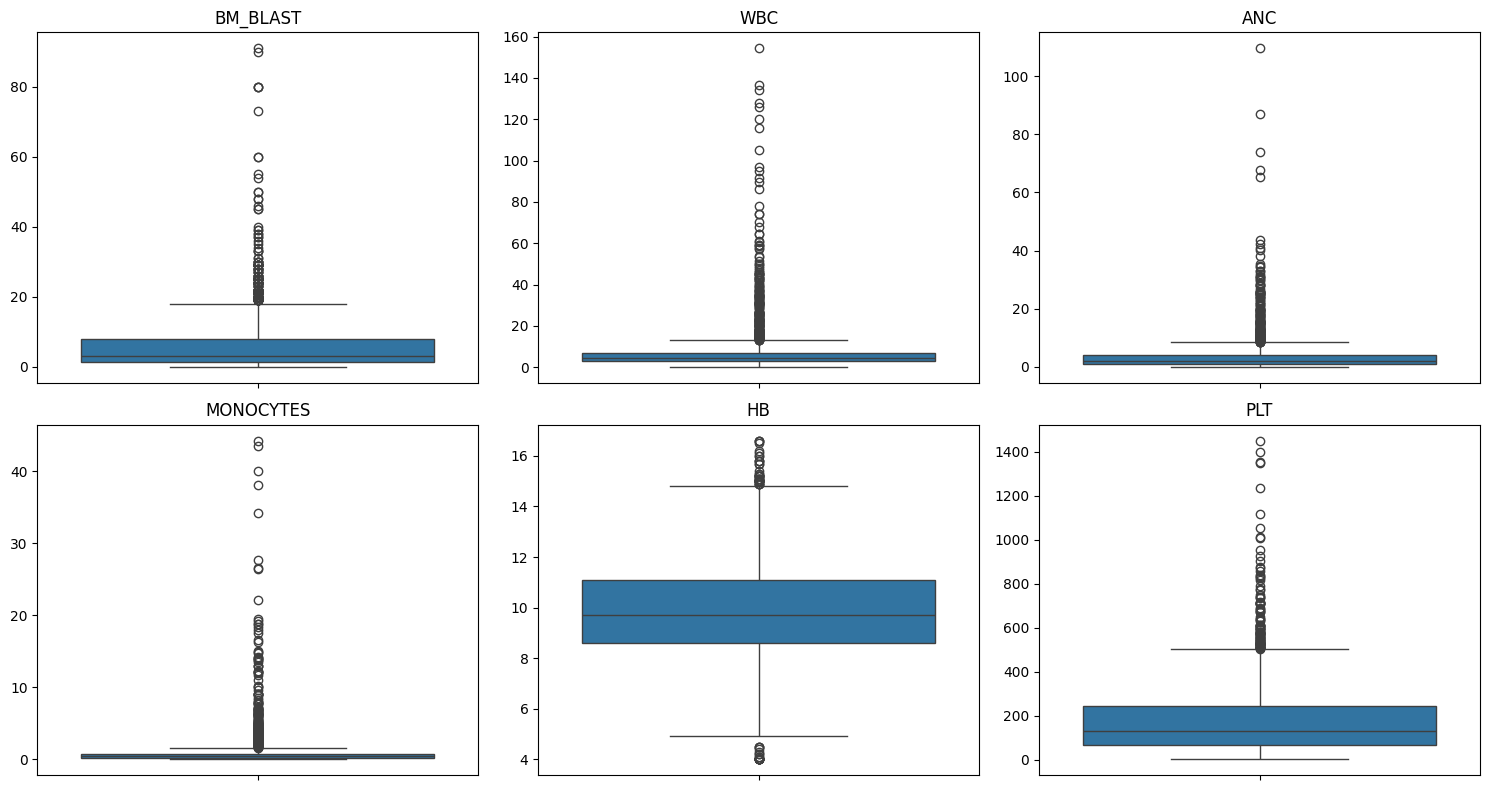

In [13]:
cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3

plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    
    plt.subplot(row,col,index + 1)
    plt.title(cl)
    sns.boxplot(df[cl])

plt.tight_layout()
plt.show()  

In [14]:
# Clinical Data

cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3


plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    q1 = df.select(pl.col(cl).quantile(0.25)).item()
    q3 = df.select(pl.col(cl).quantile(0.75)).item()
    
    iqr = q3 - q1
    
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df.filter(
        (pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound)
    )
    

    # Winsorisation : caper les valeurs extrêmes
    df = df.with_columns(
        pl.when(pl.col(cl) < lower_bound).then(lower_bound)
        .when(pl.col(cl) > upper_bound).then(upper_bound)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    
    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")


Number of outliers in column : BM_BLAST is : 181
Number of outliers in column : WBC is : 215
Number of outliers in column : ANC is : 187
Number of outliers in column : MONOCYTES is : 332
Number of outliers in column : HB is : 58
Number of outliers in column : PLT is : 104


<Figure size 1500x800 with 0 Axes>

In [15]:
df["CENTER"].value_counts()

CENTER,count
str,u32
"""HMS""",83
"""UOB""",88
"""RMCN""",199
"""CCH""",159
"""DUS""",455
…,…
"""VU""",33
"""UMG""",26
"""HIAE""",47


In [16]:


cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

for cl in cl_quantitative_var:
    mean = df.select(pl.col(cl).mean()).item()
    std = df.select(pl.col(cl).std()).item()

    z_scores = df.select(((pl.col(cl) - mean) / std).alias("z"))

    # On ajoute les Z-scores temporairement au DataFrame
    df_with_z = df.with_columns(((pl.col(cl) - mean) / std).alias(f"z_{cl}"))

    # Filtrer les outliers : abs(Z) > 3
    outliers = df_with_z.filter(pl.col(f"z_{cl}").abs() > 3)
    
    
    # Median
    median_val = df.select(pl.col(cl).median()).item()

    df = df.with_columns(
        pl.when((pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound))
        .then(median_val)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    # # Winsorisation : caper les valeurs extrêmes
    # df = df.with_columns(
    #     pl.when(pl.col(cl) < lower_bound).then(lower_bound)
    #     .when(pl.col(cl) > upper_bound).then(upper_bound)
    #     .otherwise(pl.col(cl))
    #     .alias(cl)
    # )

    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")

Number of outliers in column : BM_BLAST is : 0
Number of outliers in column : WBC is : 0
Number of outliers in column : ANC is : 0
Number of outliers in column : MONOCYTES is : 0
Number of outliers in column : HB is : 0
Number of outliers in column : PLT is : 0


# ENCODING

In [17]:
df["CENTER"].value_counts() # Catecorigal => Nominal , without any order

CENTER,count
str,u32
"""UOXF""",50
"""FLO""",68
"""VU""",33
"""KI""",900
"""DUTH""",66
…,…
"""UOB""",88
"""UMG""",26
"""DUS""",455


In [18]:
import category_encoders as ce

df_pd = df.to_pandas()

encoder = ce.BinaryEncoder(cols=["CENTER"])
df_encoded = encoder.fit_transform(df_pd)

df = pl.from_pandas(df_encoded)

df

# On encode avec le binary encoder car il n'intorduit pas d'ordre artificiel + n'explose pas le nombre de colonne + correct pour bcp de categories !

ID,CENTER_0,CENTER_1,CENTER_2,CENTER_3,CENTER_4,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str
"""P132697""",0,0,0,0,1,14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…"
"""P132698""",0,0,0,0,1,1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx"""
"""P116889""",0,0,0,0,1,15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…"
"""P132699""",0,0,0,0,1,1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…"
"""P132700""",0,0,0,0,1,6.0,13.29925,8.5,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",1,0,1,1,1,1.0,3.7,2.53,0.53,8.9,499.0,"""46,xy[20]"""
"""P121829""",1,0,1,1,1,0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…"
"""P121830""",1,0,1,1,1,0.0,1.8,0.55,0.29,9.4,86.0,"""46,xy,del(20)(q11.2q13.1)[4]/4…"


In [ ]:
# DETECTION DES DELETONS D'UN FRAGMENT DE CHROMOSOME

df["CYTOGENETICS"].to_numpy()

array(['46,xy,del(20)(q12)[2]/46,xy[18]', '46,xx',
       '46,xy,t(3;3)(q25;q27)[8]/46,xy[12]', ...,
       '46,xy,del(20)(q11.2q13.1)[4]/45,xy,idem,-7[16]',
       '46,xx,del(1)(p34)[5]/45,xx,sl,-18[12]/46,xx,sdl,+8[2]/46,xx[1]',
       '46,xy[20]'], shape=(3323,), dtype=object)